# Housing Price Prediction using FF Neural Network and Linear Regression

## Import necessary libraries

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Load and preprocess the data

In [3]:
# Load data
data = pd.read_excel("Data/WAHousePrice.xlsx")

# Features and target
X = data[["statezip", "sqft_living"]]
X = pd.get_dummies(X, columns=["statezip"])
y = np.log(data["price"])  # log-transformed price

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Get the indices for train and test sets for later use
train_idx = X_train.index
test_idx = X_test.index

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)


Train set size: 3185
Test set size: 1366


## Define and train the neural network model

In [4]:
num_epochs = 2000
learning_rate = 0.1

# Define the model
class HousingModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 3)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        return self.fc2(x)

model = HousingModel(X_train.shape[1])

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train.view(-1, 1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [100/2000], Loss: 7.7043
Epoch [200/2000], Loss: 3.6576
Epoch [300/2000], Loss: 2.2547
Epoch [400/2000], Loss: 1.6337
Epoch [500/2000], Loss: 1.1322
Epoch [600/2000], Loss: 0.7663
Epoch [700/2000], Loss: 0.5216
Epoch [800/2000], Loss: 0.3665
Epoch [900/2000], Loss: 0.2747
Epoch [1000/2000], Loss: 0.2245
Epoch [1100/2000], Loss: 0.1978
Epoch [1200/2000], Loss: 0.1848
Epoch [1300/2000], Loss: 0.1689
Epoch [1400/2000], Loss: 0.1215
Epoch [1500/2000], Loss: 0.1171
Epoch [1600/2000], Loss: 0.1131
Epoch [1700/2000], Loss: 0.1018
Epoch [1800/2000], Loss: 0.0984
Epoch [1900/2000], Loss: 0.0978
Epoch [2000/2000], Loss: 0.0977


## Evaluate the neural network

In [5]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test).view(-1).numpy()
    y_true = y_test.numpy()
mse_nn = mean_squared_error(y_test.numpy(), y_pred)

## Linear regression benchmark

In [5]:
# Recreate one-hot encoded zip codes
X_dummies = pd.get_dummies(data[["statezip"]], columns=["statezip"])

# Feature engineering
sqft = data["sqft_living"]
sqft2 = sqft**2


# Create interaction terms
X_sqft = X_dummies.mul(sqft, axis=0)
X_sqft.columns = [f"{col}_x_sqft" for col in X_sqft.columns]

X_sqft2 = X_dummies.mul(sqft2, axis=0)
X_sqft2.columns = [f"{col}_x_sqft2" for col in X_sqft2.columns]

# Combine all features
X_benchmark = pd.concat([X_dummies, X_sqft, X_sqft2], axis=1)

# Combine all features
X_benchmark = pd.concat([X_dummies, X_sqft, X_sqft2], axis=1)

# Align with neural net train/test split
X_train_b = X_benchmark.loc[train_idx]
X_test_b = X_benchmark.loc[test_idx]
y_train_b = y.loc[train_idx]
y_test_b = y.loc[test_idx]

# Fit linear regression (no intercept)
linreg = LinearRegression(fit_intercept=False)
linreg.fit(X_train_b, y_train_b)

# Predict
y_pred_b = linreg.predict(X_test_b)

# Evaluate
mse_b = mean_squared_error(y_test_b, y_pred_b)

## Fit a random forest

In [6]:
# Fit random forest
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_b, y_train_b)
# Predict
y_pred_rf = rf.predict(X_test_b)
# Evaluate
mse_rf = mean_squared_error(y_test_b, y_pred_rf)

## Naive benchmark

In [7]:
naive_pred = [y_train.mean().item()] * len(y_test)
naive_mse = mean_squared_error(y_test.numpy(), naive_pred)

## Compare performance of the three methods

In [24]:
print(f"Naive Benchmark MSE: {naive_mse:.4f}")
print(f"Linear Regression Benchmark MSE: {mse_b:.4f}")
print(f"Neural Network MSE: {mse_nn:.4f}")
print(f"Random Forest MSE: {mse_rf:.4f}")

Naive Benchmark MSE: 0.3088
Linear Regression Benchmark MSE: 0.1345
Neural Network MSE: 0.1151
Random Forest MSE: 0.1067


## Plot the colors implied by the hidden layers

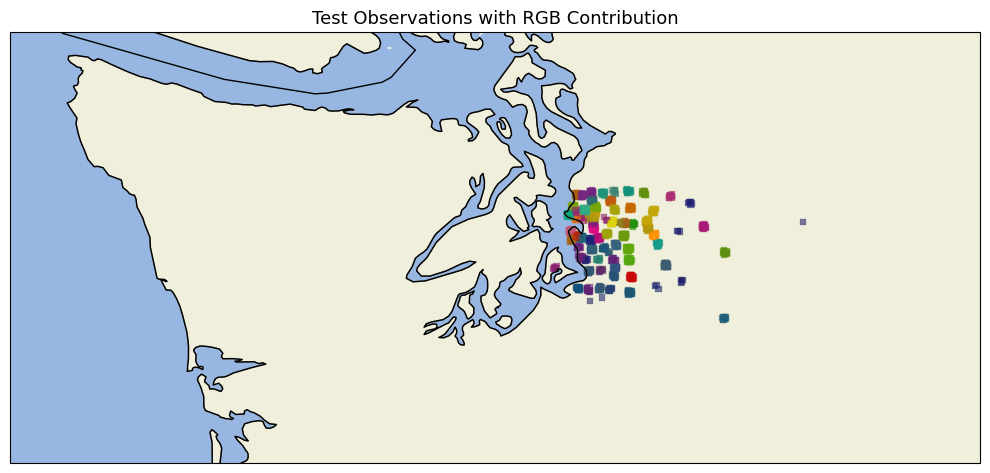

In [ ]:
# Get dummy ZIP columns and their indices
zip_dummies = [col for col in X.columns if col.startswith("statezip_")]
zip_indices = [X.columns.get_loc(col) for col in zip_dummies]
zip_codes = [col.split("_")[1] for col in zip_dummies]

# Extract ZIP dummy weights from input to hidden layer
with torch.no_grad():
    zip_weights = model.fc1.weight[
        :, zip_indices
    ].T.numpy() 

# Get which ZIP code each test observation corresponds to
X_test_df = pd.DataFrame(X_test, columns=X.columns)
zip_only_test = X_test_df.iloc[:, zip_indices]
zip_idx_test = zip_only_test.values.argmax(axis=1) 

# Get RGB contribution from the ZIP dummy for each test obs
rgb_contribs = zip_weights[zip_idx_test] 
test_zips = [zip_codes[i] for i in zip_idx_test]

# Build DataFrame
test_contrib_df = pd.DataFrame(rgb_contribs, columns=["R", "G", "B"])
test_contrib_df["GEOID"] = [z.replace("WA ", "") for z in test_zips]

# Load ZIP coordinates
coords_df = pd.read_csv("Data/ZipCodesNat.csv")
coords_df["GEOID"] = coords_df["GEOID"].astype(str).str.replace("WA ", "", regex=False)

# Merge with contributions
merged_test_df = pd.merge(test_contrib_df, coords_df, on="GEOID", how="left")

# Normalize RGB to [0, 1]
rgb = merged_test_df[["R", "G", "B"]].values
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

# Extract coordinates
lats = merged_test_df["INTPTLAT"]
lons = merged_test_df["INTPTLONG"]

# Add random jitter to lat/lon to separate overlapping points
jitter_strength = 0.01
lats_jittered = lats + np.random.uniform(
    -jitter_strength, jitter_strength, size=lats.shape
)
lons_jittered = lons + np.random.uniform(
    -jitter_strength, jitter_strength, size=lons.shape
)

# Plot with jittered coordinates
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-125, -120.5, 46.5, 48.5], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.STATES, edgecolor="gray")
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Scatter plot with jittered coordinates
ax.scatter(
    lons_jittered,
    lats_jittered,
    color=rgb,
    s=20,
    marker="s",
    linewidths=0.2,
    alpha=0.6,
    transform=ccrs.PlateCarree(),
)

plt.title("Test Observations with RGB Contribution", fontsize=13)
plt.tight_layout()
plt.show()